# Attribute 3 - Native Bush Proximity
#### Rationale:
Close to a road (for active reconstruction), close to a seed source (Mature or Regen polygon)  to facilitate natural seed dispersal into active or passive recon sites. Measure distance between same realms to ensure habitat is suitable for seeds within each patch – e.g. Not wetland to forest as they may share few species. Leave roads for now, issues with e.g. motorways may be close but not provide access.

#### Data layers
Landcover database link
LINZ Road centre lines database link 

#### Scoring
- 1. : Within 50 m of a mature or regen polygon of the same realm
- 0.8 : Within 50-100 m of a mature or regen polygon of the same realm
- 0.6 : Within 100-200 m of a mature or regen  polygon  of the same realm
- 0.4 : Within 200-500 m of a mature or regen polygon  of the same realm
- 0. : Everything else


In [1]:
import json
import math
import os
from os import listdir
from rasterio.enums import Resampling

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pyproj
import rasterio
from rasterio.transform import from_origin
from shapely.geometry import Point, Polygon, box

from constants import small_polygon_threshold, m2_to_ha, x_resolution, y_resolution, keep_cols, keep_cols_catch
from gis_analysis_functions import priority_stack_n_layers

# Load

In [2]:
%%time
# area of interest
aoi = gpd.read_file("../BaseLayersEco-index/Eco-index_Catchments_v080623.gpkg")
aoi.sindex
aoi.shape

CPU times: total: 125 ms
Wall time: 453 ms


(96, 5)

In [18]:
%%time
## This gets us the existing native vegetation
lcs = gpd.read_file('../BaseLayersEco-index/Eco-index_LandCoverSnapshot__Catchments_v290824.gpkg')
lcs.sindex
lcs.shape

CPU times: total: 7.27 s
Wall time: 7.3 s


(519876, 7)

In [19]:
%%time
## This ensures the areas we are proposing are in the right realm
epr = gpd.read_file('../BaseLayersEco-index/Eco-index_EcosystemProjector__Catchments_v290824.gpkg')
epr.sindex
epr.shape

CPU times: total: 703 ms
Wall time: 706 ms


(1486, 4)

In [20]:
%%time
restorable = gpd.read_file('../BaseLayersEco-index/Eco-index_RestorableAreas_v290824.gpkg')
restorable.sindex
restorable.shape

CPU times: total: 750 ms
Wall time: 745 ms


(28903, 1)

In [21]:
%%time
aoi_bigger = aoi.copy()
aoi_bigger['geometry'] = aoi_bigger.buffer(750)
aoi_bigger.sindex
aoi_bigger.to_file('../OutputArtifacts/A03_NativeVegetationProximity/A03_IntermediateLayers/aoi_bigger_20240829.gpkg')

CPU times: total: 8min 45s
Wall time: 8min 46s


# Load Table of Truth
We only care about proximity from certain classes:
- `Alpine Grass/Herbfield`
- `Indigenous Forest`
- `Fernland`
- `Flaxland`
- `Manuka and/or Kanuka`
- `Sub Alpine Shrubland`
- `Broadleaved Indigenous Hardwoods`
- `Tall Tussock Grassland`
- `Matagouri or Grey Scrub`
- `Herbaceous Freshwater Vegetation`
- `Deciduous Hardwoods`, only where wetland context = `Yes`

In [22]:
tot = pd.read_csv('../BaseLayersEco-index/TableOfTruth_LCDB_Mapping.csv')

tot = tot[['LCDB_5 Land cover class', 'LCDB Wetland context', 'Land cover status',
       'Existing Natural Area', 'Eco-Index Realm (Generalised, not IUCN)','LCDB Class "Description" for heat map attributes #3  and #7 - use Native Veg and also Wetland with exotic canopy']]
# # tot = tot[['LCDB_5 Land cover class', 'LCDB Wetland context', 'Land cover status']].copy()
    
anys = tot.loc[tot['LCDB Wetland context'] == 'any', :].copy()
anys['LCDB Wetland context'] = anys.shape[0]*[['Yes', 'No']]

tot_fixed = pd.concat([
    anys.explode('LCDB Wetland context'), # the ones we have added
    tot[tot['LCDB Wetland context'] != 'any']
]).reset_index(drop=True)

# # add cols for easier merging
tot_fixed['Name_2018'] = tot_fixed['LCDB_5 Land cover class'].copy()
tot_fixed['Wetland_18'] = tot_fixed['LCDB Wetland context'].str.lower()
tot_fixed['Realm'] = tot_fixed['Eco-Index Realm (Generalised, not IUCN)'].copy()
tot_fixed['Indig'] = tot_fixed['LCDB Class "Description" for heat map attributes #3  and #7 - use Native Veg and also Wetland with exotic canopy'].copy()
# tot_fixed = tot_fixed.drop(['LCDB Wetland context', 
#                             'LCDB_5 Land cover class', 
#                             'Eco-Index Realm (Generalised, not IUCN)'
#                            'LCDB Class "Description" for heat map attributes #3  and #7'], axis=1)

tot_fixed_indig = tot_fixed[(~pd.isna(tot_fixed['Indig'])) | 
                            ((tot_fixed.Name_2018=='Deciduous Hardwoods') & (tot_fixed['LCDB Wetland context']=='Yes'))].copy()

### Get Realms

In [23]:
tot_pnvw = pd.read_csv(
    "../BaseLayersEco-index/TableOfTruth_PNVW_Mapping.csv"
)

tot_pnvw = tot_pnvw[
    [
        "Potential Natural Vegetation and Wetland Type",
        "Eco_index Realm (not same as Costanza or IUCN)",
    ]
].copy()

tot_pnvw = tot_pnvw.rename(
    {
        "Potential Natural Vegetation and Wetland Type": "PNVWmacron",
        "Eco_index Realm (not same as Costanza or IUCN)": "Realm",
    },
    axis=1,
)
tot_pnvw = pd.concat([tot_pnvw, 
    pd.DataFrame(
        {
            "PNVWmacron": [
                "Unclassified",
                "unclassified",
                "Hall's tōtara-miro/kāmahi-southern rata broadleaf forest",
                "Hall's totara-miro/kamahi-southern rata broadleaf forest",
                "Hall's tōtara-miro-rimu/kāmahi-southern rata-broadleaf forest"
            ],
            "Realm": ["unclassified", "unclassified", "Terrestrial", "Terrestrial", "Terrestrial"],
        }
    )]
)
tot_pnvw["PNVWmacron"] = tot_pnvw.PNVWmacron.str.replace("_", " ")

tot_pnvw = pd.concat([
    tot_pnvw,
    pd.DataFrame({'PNVWmacron':['Wetland_Unclassified', "Hall's tōtara-miro/kamahi-southern rata broadleaf forest"], 'Realm':['Freshwater Wetland', 'Terrestrial']})
])

In [28]:
epr

,Catchment,EcosystemType,Realm,geometry
0,Ākitio,Marsh,Freshwater Wetland,"MULTIPOLYGON (((1873141.895 5527977.659, 18731..."
1,Ākitio,Mātai-tōtara-kahikatea-rimu/broadleaf-fuchsia ...,Terrestrial,"MULTIPOLYGON (((1857234.32 5505017.941, 185720..."
2,Ākitio,Rimu-miro/kāmahi-red beech-hard beech forest,Terrestrial,"MULTIPOLYGON (((1872389.237 5493911.842, 18723..."
3,Ākitio,unclassified,unclassified,"MULTIPOLYGON (((1883170.032 5493079.842, 18831..."
4,Ākitio,Rimu-mātai-miro-tōtara/kāmahi forest,Terrestrial,"MULTIPOLYGON (((1872989.386 5493191.447, 18729..."
...,...,...,...,...
1481,Whangārei,Kauri/taraire-kohekohe-tawa forest,Terrestrial,"MULTIPOLYGON (((1730810.914 6038182.632, 17308..."
1482,Whangārei,Rimu/tawa-kamahi forest,Terrestrial,"MULTIPOLYGON (((1726866.691 6006300.038, 17268..."
1483,Whangārei islands,unclassified,unclassified,"MULTIPOLYGON (((1757551.784 6026705.403, 17575..."
1484,Whangārei islands,Kauri/taraire-kohekohe-tawa forest,Terrestrial,"MULTIPOLYGON (((1753515.465 6026233.022, 17535..."


In [29]:
%%time
# epr_realm = epr.merge(tot_pnvw, left_on='EcosystemType', right_on='PNVWmacron', how='left')
# epr_realm.sindex

# make sure we have mappings for all EcosystemTypes:
assert epr[epr.Realm.isna()].EcosystemType.unique().shape[0] == 0

realms = epr[['Catchment', 'Realm', 'geometry']].dissolve(['Catchment', 'Realm'])
realms = realms.reset_index().explode().reset_index(drop=True)

CPU times: total: 1min 18s
Wall time: 1min 18s


In [30]:
%%time
restorable_realms = realms.overlay(restorable)

CPU times: total: 18min 35s
Wall time: 18min 37s


C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 3408 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


In [31]:
restorable_realms.to_file('../OutputArtifacts/A03_NativeVegetationProximity/A03_IntermediateLayers/restorable_realms_20240829.gpkg')

### Create Search area

In [32]:
%%time
ena = lcs[lcs.Realm.isin(['Freshwater', 'Terrestrial'])].copy()
ena = ena.merge(tot_fixed_indig[['Name_2018', 'Wetland_18', 'Indig']], how='inner', left_on=['LCDBLandCoverClass', 'LCDBWetlandContext'], right_on=['Name_2018', 'Wetland_18'])
# ena = ena.explode(index_parts=False)
# ena = ena.reset_index(drop=True)
ena.sindex

ena_aoi_bigger = ena[['LandCoverStatus', 'Realm', 'geometry']].overlay(aoi_bigger[['Catchment', 'geometry']])
ena_aoi_bigger.to_file('../OutputArtifacts/A03_NativeVegetationProximity/A03_IntermediateLayers/ena_aoi_bigger_20240829.gpkg')
ena_aoi_bigger.sindex

CPU times: total: 4min 7s
Wall time: 4min 8s


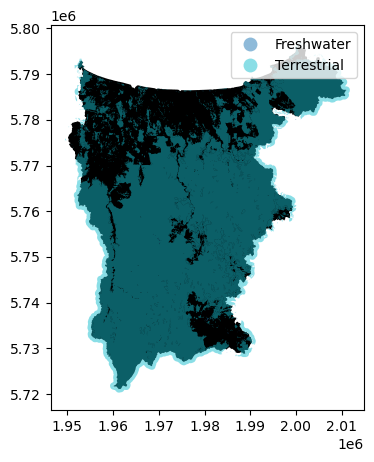

In [33]:
fig, ax = plt.subplots(figsize=(12,5))
aoi[aoi['Catchment']=='Ōpōtiki'].plot(color='black', ax=ax)
ena_aoi_bigger[ena_aoi_bigger['Catchment']=='Ōpōtiki'].plot(column='Realm', legend=True, ax=ax, alpha=.5)
plt.show()

# PER CATCHMENT

In [38]:
import time
from pathlib import Path

# keep_cols = ['Attribute', 'PixelScore', 'PixelDesc', 'geometry']
buffer_distances = [50, 100, 200, 500]
buffer_distance_to_pixel_score = {50:10, 100:8, 200:6, 500:4}
range_desc_lookup = {
    500: '200-500m',
    200: '100-200m',
    100: '50-100m',
    50: '0-50m'
}

# gdfs = []
for n_catch, catchment in enumerate(ena_aoi_bigger.Catchment.sort_values().unique()):
# for n_catch, catchment in enumerate(['Ruamahanga']):
# for n_catch, catchment in enumerate(['Hutt']):
    if n_catch < 17:
        # continue
        sub_aoi = aoi[aoi.Catchment == catchment].copy()
        sub_aoi.sindex
        
        start_time = time.time()
        current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time))
        print(f"\n{n_catch}_{catchment.upper()}      {current_time}")
    
        # We know that any ena that is more than 500m from aoi won't be used in this attribute
        #    so we remove those for speed
        sub_aoi_buff = ena_aoi_bigger[ena_aoi_bigger.Catchment==catchment].copy()
        
        sub_terr = sub_aoi_buff[sub_aoi_buff.Realm =='Terrestrial'].copy()
        sub_terr.sindex
        
        sub_fre = sub_aoi_buff[sub_aoi_buff.Realm =='Freshwater'].copy()
        sub_fre.sindex
    
        # sub_aoi_buff['geometry'] = sub_aoi_buff.buffer(max(buffer_distances),resolution=4)
        # sub_terr = gpd.sjoin(terr, sub_aoi_buff, how="inner", predicate="intersects")
        
        unstacked_layers = []
        
        for buffer_distance in buffer_distances[:]:
            # Restorable Realms
            sub_restorable_realms = restorable_realms[restorable_realms.Catchment==catchment].copy()
    
            # Terrestrial Areas
            current_realm = 'Terrestrial'
            formatted_time_diff = time.strftime("%M:%S", time.gmtime(time.time() - start_time))
            print(f"    Starting {buffer_distance}m, {formatted_time_diff} elapsed")
            prox = sub_terr.copy()
            prox.sindex
            prox['geometry'] = sub_terr['geometry'].buffer(buffer_distance, resolution=4)
            prox = prox.dissolve()
            prox['PrioOption'] = 'Native Vegetation Proximity'
            prox['PixelScore'] = buffer_distance_to_pixel_score[buffer_distance]
            prox['PixelDesc'] = f'Between {range_desc_lookup[buffer_distance]} from a Mature/Regenerating area of same realm ({current_realm})'
            prox = prox.overlay(sub_restorable_realms[sub_restorable_realms.Realm == current_realm][['geometry']])
    
            formatted_time_diff = time.strftime("%M:%S", time.gmtime(time.time() - start_time))
            print(f"        Terrestrial Buffer complete {formatted_time_diff} elapsed")
            if prox is not None:
                prox = prox.set_crs('EPSG:2193')
                prox.to_file(f'../OutputArtifacts/A03_NativeVegetationProximity/A03_IntermediateLayers/catchments/{str(n_catch).zfill(3)}_{catchment}_{buffer_distance}m_terr.gpkg')
               
            # Freshwater Areas
            current_realm = 'Freshwater Wetland'
            start = time.time()
            proxfre = sub_fre.copy()
            proxfre.sindex
            proxfre = proxfre.dissolve()
            proxfre['geometry'] = proxfre['geometry'].buffer(buffer_distance, resolution=4)
            proxfre['PrioOption'] = 'Native Vegetation Proximity'
            proxfre['PixelScore'] = buffer_distance_to_pixel_score[buffer_distance]
            proxfre['PixelDesc'] = f'Between {range_desc_lookup[buffer_distance]} from a Mature/Regenerating area of same realm ({current_realm})'
            proxfre = proxfre.overlay(sub_restorable_realms[sub_restorable_realms.Realm == current_realm][['geometry']])
            if proxfre is not None:
                proxfre.to_file(f'../OutputArtifacts/A03_NativeVegetationProximity/A03_IntermediateLayers/catchments/{str(n_catch).zfill(3)}_{catchment}_{buffer_distance}m_fre.gpkg')
            
            formatted_time_diff = time.strftime("%M:%S", time.gmtime(time.time() - start_time))
            print(f"        Freshwater Buffer complete {formatted_time_diff} elapsed")
            comb = gpd.GeoDataFrame(pd.concat([prox, proxfre]))
            if comb is None:
                continue
                
            comb.to_file(f'../OutputArtifacts/A03_NativeVegetationProximity/A03_IntermediateLayers/catchments/{str(n_catch).zfill(3)}_{catchment}_{buffer_distance}m_comb.gpkg')
            if comb.shape[0] > 0:
                unstacked_layers.append(comb)
    
        formatted_time_diff = time.strftime("%M:%S", time.gmtime(time.time() - start_time))
        print(f'    Stacking all radius, {formatted_time_diff} elapsed')
    
        if len(unstacked_layers) > 0:
            catch_stacked = priority_stack_n_layers(unstacked_layers)
            catch_stacked = catch_stacked.overlay(sub_aoi[['geometry']], keep_geom_type=True)
            catch_stacked = catch_stacked.explode()
            catch_stacked["Area_ha"] = catch_stacked.area * m2_to_ha
            catch_stacked = catch_stacked[catch_stacked.Area_ha > small_polygon_threshold].copy().reset_index(drop=True)
            catch_stacked["Area_ha"] = catch_stacked["Area_ha"].round(2)
            
            catch_stacked[keep_cols_catch].to_file(f'../OutputArtifacts/A03_NativeVegetationProximity/A03_Catchments/{str(n_catch).zfill(3)}_{catchment}_proximity_comb_20240829.gpkg')
            
            gdfs.append(catch_stacked)
        formatted_time_diff = time.strftime("%M:%S", time.gmtime(time.time() - start_time))
        print(f'    Catchment Complete, {formatted_time_diff} elapsed')


0_APARIMA      2024-09-17 09:04:33
    Starting 50m, 00:00 elapsed
        Terrestrial Buffer complete 00:01 elapsed
        Freshwater Buffer complete 00:02 elapsed
    Starting 100m, 00:02 elapsed
        Terrestrial Buffer complete 00:03 elapsed
        Freshwater Buffer complete 00:03 elapsed
    Starting 200m, 00:04 elapsed
        Terrestrial Buffer complete 00:05 elapsed
        Freshwater Buffer complete 00:05 elapsed
    Starting 500m, 00:05 elapsed
        Terrestrial Buffer complete 00:07 elapsed
        Freshwater Buffer complete 00:08 elapsed
    Stacking all radius, 00:08 elapsed
    Catchment Complete, 00:22 elapsed

1_ASHBURTON-HINDS      2024-09-17 09:04:56
    Starting 50m, 00:00 elapsed
        Terrestrial Buffer complete 00:01 elapsed
        Freshwater Buffer complete 00:01 elapsed
    Starting 100m, 00:02 elapsed
        Terrestrial Buffer complete 00:03 elapsed
        Freshwater Buffer complete 00:03 elapsed
    Starting 200m, 00:03 elapsed
        Terrestrial 

In [39]:
concatenated_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
concatenated_gdf = concatenated_gdf.explode()
concatenated_gdf.sindex

small_polygon_threshold = .005 #threshold
concatenated_gdf['Area_ha'] = concatenated_gdf.area * m2_to_ha
concatenated_gdf = concatenated_gdf[concatenated_gdf.Area_ha > small_polygon_threshold]#.copy().reset_index(drop=True)
concatenated_gdf['Area_ha'] = concatenated_gdf['Area_ha'].round(2)
concatenated_gdf.drop_duplicates()[keep_cols_catch].to_file(
    "../OutputArtifacts/A03_NativeVegetationProximity/A03_NativeVegetationProximity_20240829.gpkg"
)

In [37]:
# from gis_analysis_functions import rasterize_and_save
# # Raster
# rasterize_and_save(aoi, concatenated_gdf, 10, 10, "output_layers/attr03/03_Vegetation_Proximity_10m_20240828.tif")
# current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(time.time()))
# print(f'Completed raster \n{current_time}')